# Part 4: Student Performance Analysis & Prediction
Analysing student data, creating visualizations, and building an ML model to predict pass/fail.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Task 1: Data Exploration with Pandas

In [2]:
# Loading the dataset
df = pd.read_csv("students.csv")

# 1. First 5 rows
print("--- First 5 Rows ---")
df.head()

--- First 5 Rows ---


,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [3]:
# 2. Shape and data types
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Data Types:")
print(df.dtypes)

Shape: 15 rows x 9 columns

Data Types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [4]:
# 3. Summary statistics for numeric columns
print("--- Summary Statistics ---")
df.describe()

--- Summary Statistics ---


,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [5]:
# 4. Count of pass vs fail
print("--- Pass/Fail Count ---")
print(df['passed'].value_counts())
print(f"\nPassed: {(df['passed'] == 1).sum()}, Failed: {(df['passed'] == 0).sum()}")

--- Pass/Fail Count ---
passed
1    9
0    6
Name: count, dtype: int64

Passed: 9, Failed: 6


In [6]:
# 5. Average score per subject for passing vs failing students
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("--- Average Scores (Passing Students) ---")
print(df[df['passed'] == 1][subject_cols].mean())

print("\n--- Average Scores (Failing Students) ---")
print(df[df['passed'] == 0][subject_cols].mean())

--- Average Scores (Passing Students) ---
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

--- Average Scores (Failing Students) ---
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [7]:
# 6. Student with highest overall average across subjects
df['overall_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['overall_avg'].idxmax()]
print(f"Student with highest average: {top_student['name']} ({top_student['overall_avg']:.2f})")

Student with highest average: Diana (94.00)


## Task 2: Data Visualization with Matplotlib

In [8]:
# Adding avg_score column as instructed
df['avg_score'] = df[subject_cols].mean(axis=1)

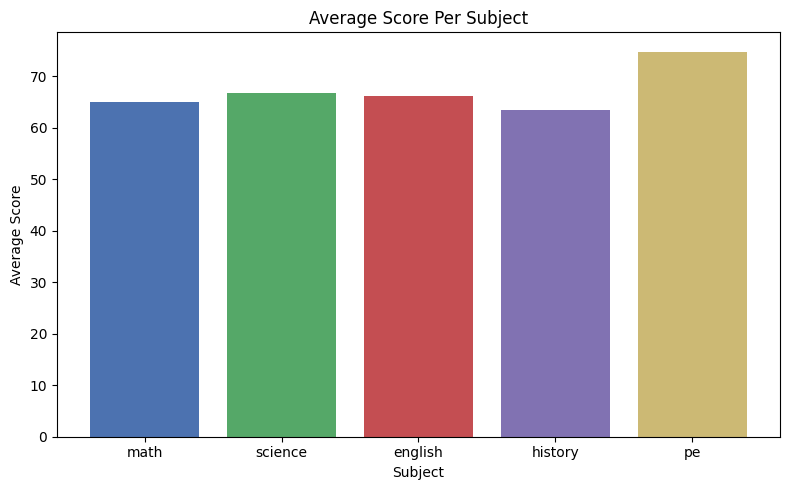

In [9]:
# Plot 1 — Bar Chart: Average score per subject
avg_per_subject = df[subject_cols].mean()

plt.figure(figsize=(8, 5))
plt.bar(subject_cols, avg_per_subject, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'])
plt.title('Average Score Per Subject')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.tight_layout()
plt.savefig('plot1_bar.png')
plt.show()

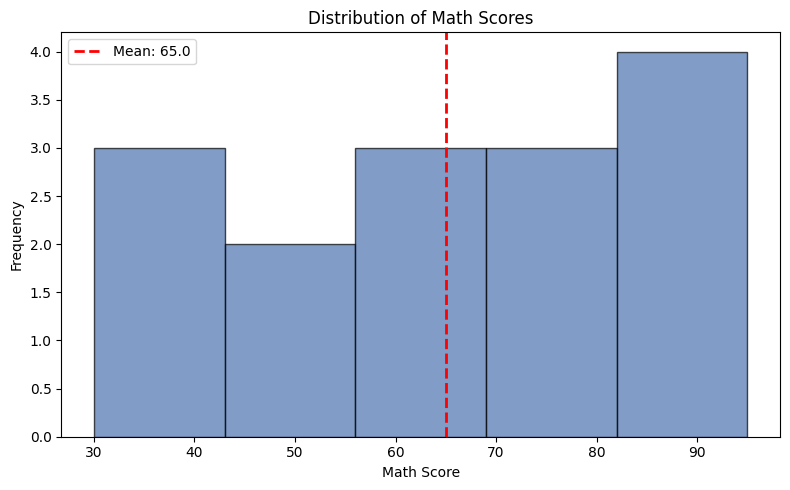

In [10]:
# Plot 2 — Histogram: Distribution of math scores with mean line
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, edgecolor='black', color='#4C72B0', alpha=0.7)
math_mean = df['math'].mean()
plt.axvline(math_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {math_mean:.1f}')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('plot2_histogram.png')
plt.show()

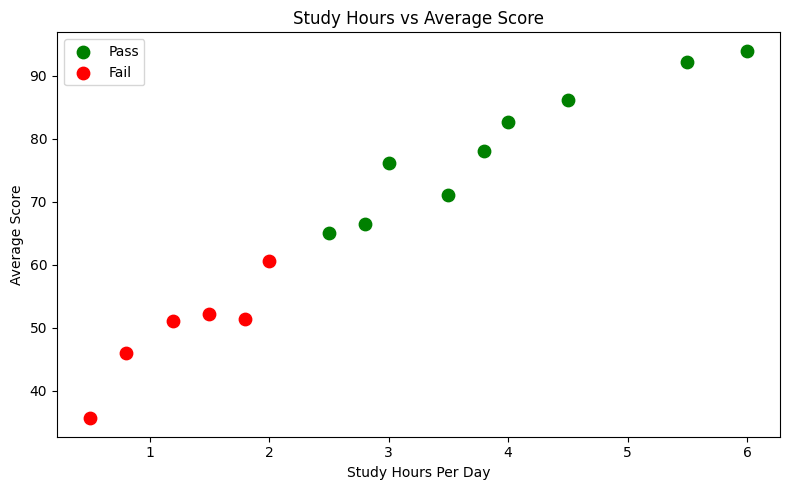

In [11]:
# Plot 3 — Scatter Plot: study hours vs avg_score, coloured by pass/fail
passed = df[df['passed'] == 1]
failed = df[df['passed'] == 0]

plt.figure(figsize=(8, 5))
plt.scatter(passed['study_hours_per_day'], passed['avg_score'], color='green', label='Pass', s=80)
plt.scatter(failed['study_hours_per_day'], failed['avg_score'], color='red', label='Fail', s=80)
plt.title('Study Hours vs Average Score')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Average Score')
plt.legend()
plt.tight_layout()
plt.savefig('plot3_scatter.png')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41228\3430541875.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


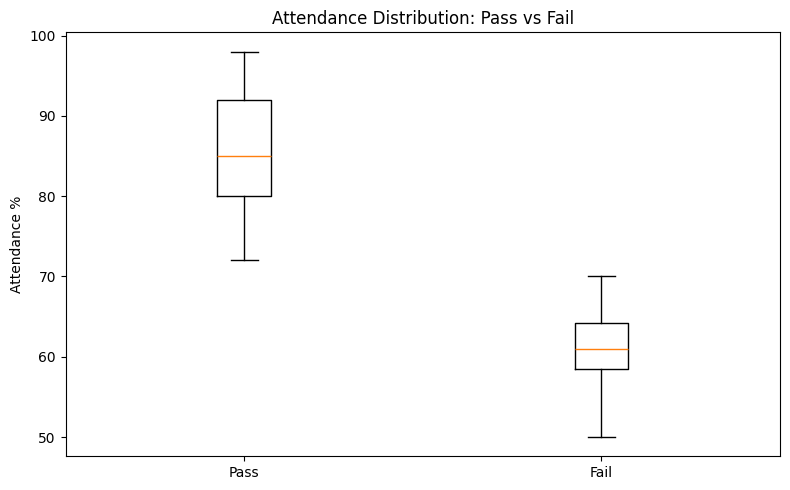

In [12]:
# Plot 4 — Box Plot: attendance distribution for pass vs fail
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title('Attendance Distribution: Pass vs Fail')
plt.ylabel('Attendance %')
plt.tight_layout()
plt.savefig('plot4_boxplot.png')
plt.show()

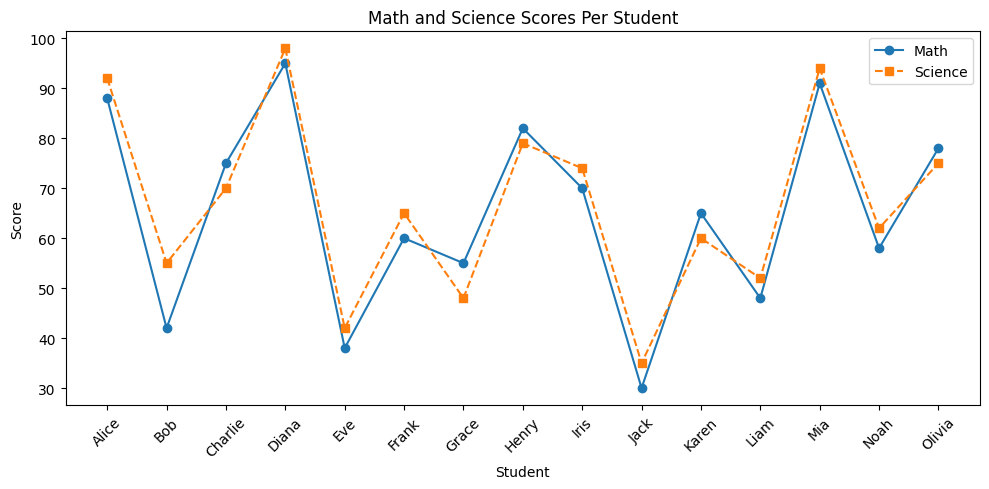

In [13]:
# Plot 5 — Line Plot: math and science scores per student
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science')
plt.title('Math and Science Scores Per Student')
plt.xlabel('Student')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('plot5_line.png')
plt.show()

## Task 3: Data Visualization with Seaborn

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41228\157786982.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Fail', 'Pass'])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_41228\157786982.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Fail', 'Pass'])


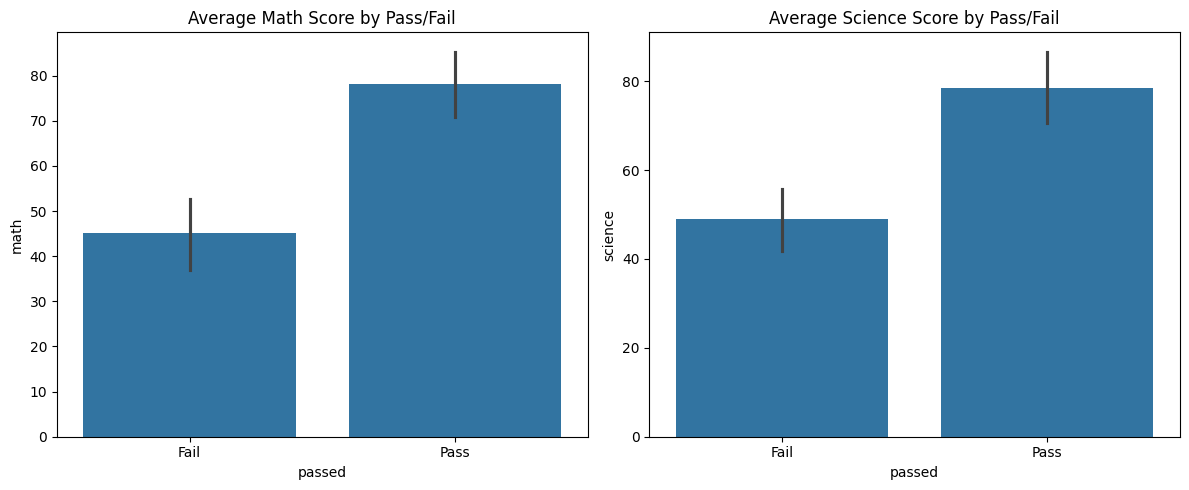

In [14]:
# Seaborn Plot 1 — Bar plots for avg math and science scores split by pass/fail
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title('Average Math Score by Pass/Fail')
ax1.set_xticklabels(['Fail', 'Pass'])

sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title('Average Science Score by Pass/Fail')
ax2.set_xticklabels(['Fail', 'Pass'])

plt.tight_layout()
plt.savefig('plot6_seaborn_bar.png')
plt.show()

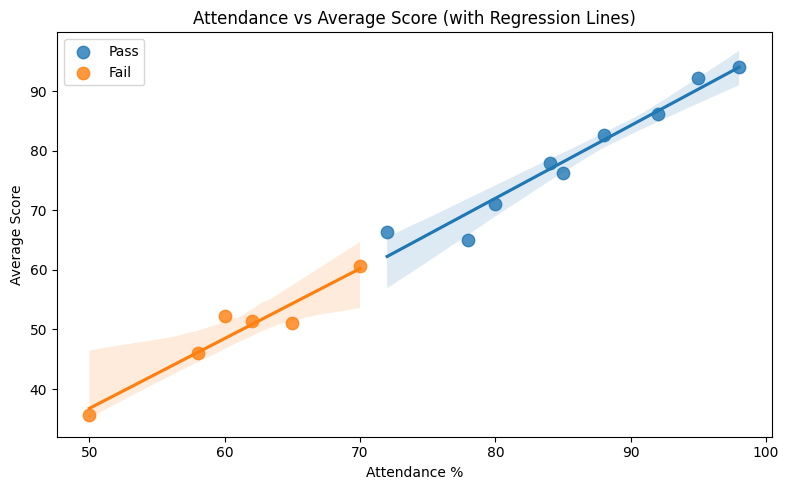

In [15]:
# Seaborn Plot 2 — Scatter with regression lines for pass and fail groups
plt.figure(figsize=(8, 5))
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', label='Pass', scatter_kws={'s': 80})
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score', label='Fail', scatter_kws={'s': 80})
plt.title('Attendance vs Average Score (with Regression Lines)')
plt.xlabel('Attendance %')
plt.ylabel('Average Score')
plt.legend()
plt.tight_layout()
plt.savefig('plot7_seaborn_scatter.png')
plt.show()

In [16]:
# Seaborn vs Matplotlib comparison:
# Seaborn was much simpler for the bar plots — one line to get mean scores grouped by pass/fail,
# whereas matplotlib would need manual grouping and calculation.
# The regression scatter plot was also easier with sns.regplot since it handles the line fitting
# automatically. Matplotlib needed more lines but gave more control over styling.

## Task 4: Machine Learning with scikit-learn

In [17]:
# Step 1 — Separating features and target, then splitting
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features — fitting only on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 12
Test set size: 3


In [18]:
# Step 2 — Training a logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

train_accuracy = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_accuracy:.2%}")

Training Accuracy: 100.00%


In [19]:
# Step 3 — Predicting on test set and showing results per student
y_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.2%}\n")

# Getting the names of test students using their original indices
test_indices = X_test.index
for i, idx in enumerate(test_indices):
    name = df.loc[idx, 'name']
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    status = "\u2705 Correct" if actual == predicted else "\u274c Wrong"
    print(f"{name:<10} | Actual: {actual} | Predicted: {predicted} | {status}")

Test Accuracy: 100.00%

Jack       | Actual: 0 | Predicted: 0 | ✅ Correct
Liam       | Actual: 0 | Predicted: 0 | ✅ Correct
Alice      | Actual: 1 | Predicted: 1 | ✅ Correct


In [20]:
# Step 4 — Feature importance based on model coefficients
coefficients = model.coef_[0]
coef_pairs = list(zip(feature_cols, coefficients))

# Sorting by absolute value to see which features matter the most
coef_pairs.sort(key=lambda x: abs(x[1]), reverse=True)

print("--- Feature Importance (sorted by |coefficient|) ---")
for name, coef in coef_pairs:
    print(f"  {name:<25} {coef:+.4f}")

--- Feature Importance (sorted by |coefficient|) ---
  english                   +0.8125
  attendance_pct            +0.5219
  study_hours_per_day       +0.4844
  pe                        +0.4750
  math                      +0.4379
  science                   +0.3230
  history                   +0.2629


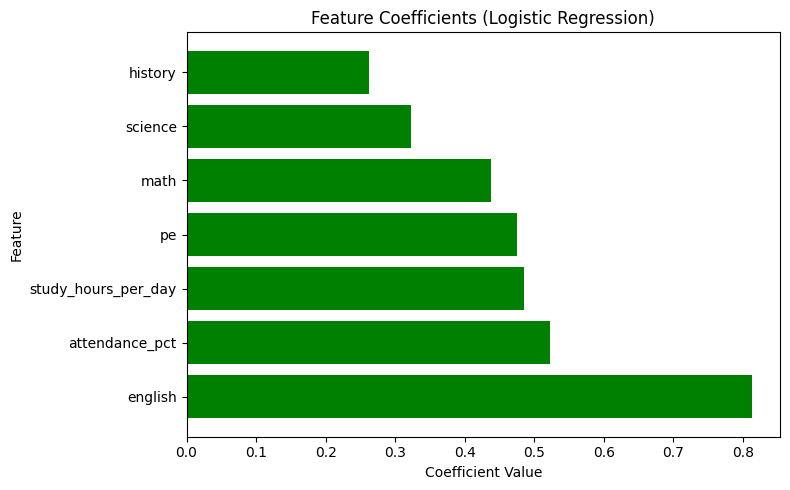

In [21]:
# Horizontal bar chart of feature coefficients
features = [p[0] for p in coef_pairs]
coefs = [p[1] for p in coef_pairs]
colors = ['green' if c > 0 else 'red' for c in coefs]

plt.figure(figsize=(8, 5))
plt.barh(features, coefs, color=colors)
plt.title('Feature Coefficients (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('plot8_feature_importance.png')
plt.show()

In [22]:
# Step 5 (Bonus) — Predicting for a new student
new_student = pd.DataFrame([{
    'math': 72, 'science': 68, 'english': 75,
    'history': 60, 'pe': 80,
    'attendance_pct': 82, 'study_hours_per_day': 3.2
}])

# Scaling using the same scaler fitted on training data
new_scaled = scaler.transform(new_student)
prediction = model.predict(new_scaled)[0]
probabilities = model.predict_proba(new_scaled)[0]

print(f"New Student Prediction: {'Pass' if prediction == 1 else 'Fail'}")
print(f"Probability — Fail: {probabilities[0]:.2%}, Pass: {probabilities[1]:.2%}")

New Student Prediction: Pass
Probability — Fail: 8.04%, Pass: 91.96%
